# 📊 Introduction to Plotting in Python
### A Step-by-Step Guide for Beginners


## 🟡 STAGE 1 — Why Should We Visualize Data?

Before we write a single line of plotting code, let's understand **why** visualization matters.

### Anscombe's Quartet

In 1973, statistician Francis Anscombe created 4 datasets that have:
- The **same mean** (average)
- The **same variance** (spread)
- The **same correlation** (relationship between x and y)
- The **same regression line**

You would think they are identical. Let's check.

Run the cell below to see their statistics:

In [1]:
!pip install scipy

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Anscombe's Quartet — 4 datasets built into seaborn
import seaborn as sns
anscombe = sns.load_dataset('anscombe')

# Show statistics for each dataset
print("📊 Statistics for each dataset:")
print(anscombe.groupby('dataset').agg({'x': ['mean', 'var'], 'y': ['mean', 'var']}).round(2))

📊 Statistics for each dataset:
           x          y      
        mean   var mean   var
dataset                      
I        9.0  11.0  7.5  4.13
II       9.0  11.0  7.5  4.13
III      9.0  11.0  7.5  4.12
IV       9.0  11.0  7.5  4.12


**👆 See? The numbers look almost the same across all 4 datasets.**

Now let's **PLOT** them and see what really happens:

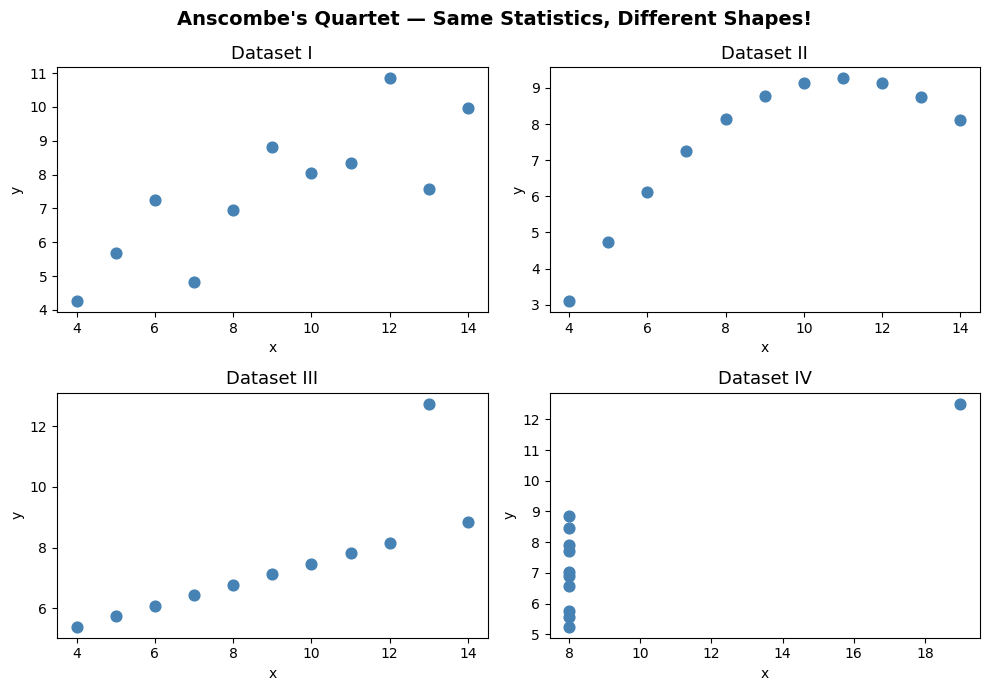

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

datasets = ['I', 'II', 'III', 'IV']
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, ds in enumerate(datasets):
    data = anscombe[anscombe['dataset'] == ds]
    axes[i].scatter(data['x'], data['y'], color='steelblue', s=60)
    axes[i].set_title(f'Dataset {ds}', fontsize=13)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

fig.suptitle("Anscombe's Quartet — Same Statistics, Different Shapes!", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 💡 Key Lesson

| Dataset | What it actually looks like |
|---------|-----------------------------|
| I       | A clean linear relationship |
| II      | A curve — not linear at all |
| III     | Linear but with one outlier |
| IV      | Vertical cluster — x barely changes |

> **The numbers lied. The plot told the truth.**  
> Always visualize your data — never trust statistics alone.

---

## 🟡 STAGE 2 — Setup and Loading Our Data

We will use a simple dataset about **30 students** — their age, study hours, exam score, and grade.

**Three libraries we'll use:**

| Library | What it does |
|---------|-------------|
| `pandas` | Load and manage data |
| `matplotlib` | Core plotting engine |
| `seaborn` | Beautiful statistical plots (built on matplotlib) |

### The magic command
```python
%matplotlib inline
```
This tells Jupyter: **show plots directly inside the notebook**, not in a separate window.

In [31]:
# ✅ Import all libraries we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ✅ Load the student dataset
df = pd.read_csv('data/students.csv', index_col='ID')

# ✅ Always peek at your data first!
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head(10)

Shape: 30 rows × 6 columns



,name,age,study_hours,score,gender,grade
ID,,,,,,
1,Alice,20,8,88,Female,A
2,Bob,21,5,72,Male,B
3,Carol,19,9,91,Female,A
4,David,22,3,55,Male,C
5,Eva,20,7,80,Female,B
6,Frank,21,6,74,Male,B
7,Grace,19,10,95,Female,A
8,Henry,23,2,48,Male,C
9,Iris,20,8,85,Female,A


**👆 Our dataset has:**
- `name`, `age`, `gender` — who the student is
- `study_hours` — how many hours they study per day
- `score` — their exam score (0–100)
- `grade` — A, B, or C

---

## 🟡 STAGE 3 — Anatomy of a Figure

Before we plot, we need to understand **how matplotlib thinks** about a chart.

```
┌─────────────────────────────────────┐  ← FIGURE  (the whole canvas)
│  ┌───────────────────────────────┐  │
│  │  Title                        │  │  ← AXES   (one chart area)
│  │                               │  │
│  │        *   *                  │  │
│  │      *       *                │  │
│  │    *                          │  │
│  │  ─────────────────────────    │  │  ← X-AXIS (horizontal)
│  │  │                            │  │  ← Y-AXIS (vertical)
│  └───────────────────────────────┘  │
└─────────────────────────────────────┘
```

### ⚠️ Common confusion: `axes` vs `axis`

| Term | Meaning |
|------|---------|
| `axis` | A single line — the x-axis OR the y-axis |
| `axes` | One complete chart area — contains **both** an x-axis and a y-axis |

> Think of `axes` as "one plot panel". A figure can have many axes (subplots).

---

## 🟡 STAGE 4 — Matplotlib Basics

### 4a. Your very first plot

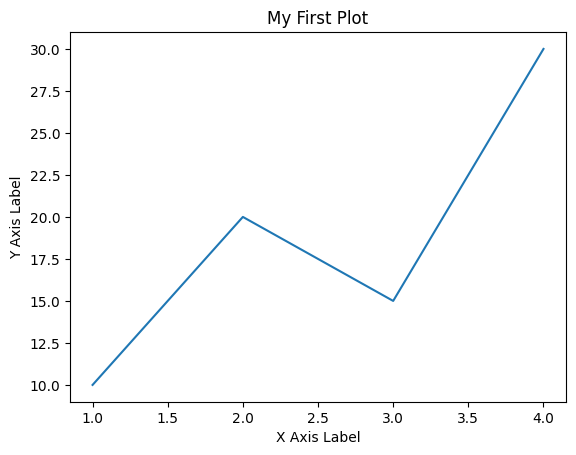

In [32]:
# The simplest possible plot
fig, ax = plt.subplots()           # create a figure + one axes

ax.plot([1, 2, 3, 4], [10, 20, 15, 30])   # x values, y values

ax.set_title('My First Plot')      # add a title
ax.set_xlabel('X Axis Label')      # label the x axis
ax.set_ylabel('Y Axis Label')      # label the y axis

plt.show()

### 4b. Histogram — What is the distribution of scores?

A **histogram** shows how often values fall into ranges (called **bins**).  
Use it for a **single numeric variable**.

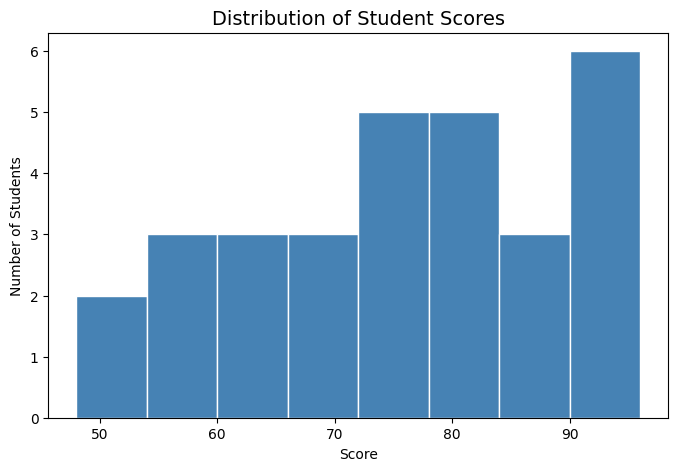

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['score'], bins=8, color='steelblue', edgecolor='white')

ax.set_title('Distribution of Student Scores', fontsize=14)
ax.set_xlabel('Score')
ax.set_ylabel('Number of Students')

plt.show()

> **What to look for:** Are most scores clustered in the middle? Are there very high or very low outliers?

### 4c. Scatter Plot — Do study hours affect scores?

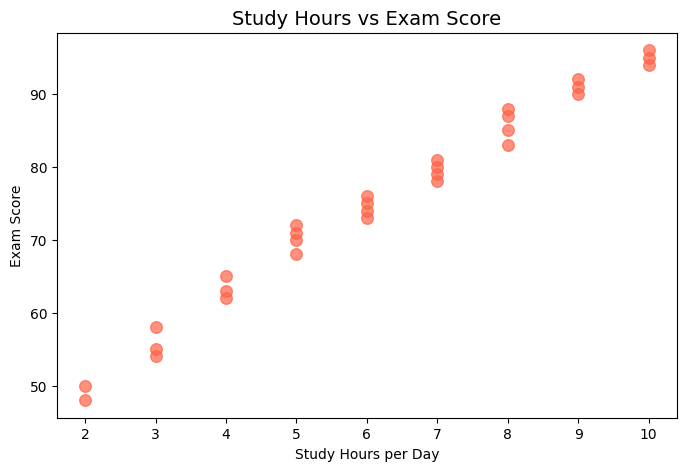

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x=df['study_hours'], y=df['score'], color='tomato', alpha=0.7, s=70)

ax.set_title('Study Hours vs Exam Score', fontsize=14)
ax.set_xlabel('Study Hours per Day')
ax.set_ylabel('Exam Score')

plt.show()

> **What to look for:** Do the dots go up as you move right? That means more study hours = higher score.

### 4d. Box Plot — How do scores compare by grade?

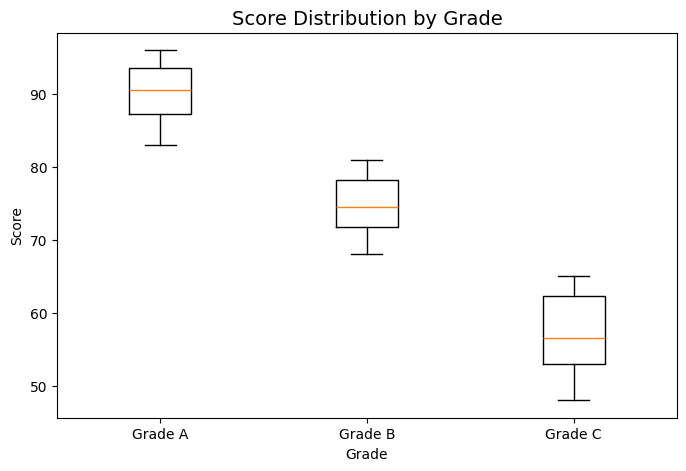

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

grade_A = df[df['grade'] == 'A']['score']
grade_B = df[df['grade'] == 'B']['score']
grade_C = df[df['grade'] == 'C']['score']

ax.boxplot([grade_A, grade_B, grade_C], labels=['Grade A', 'Grade B', 'Grade C'])

ax.set_title('Score Distribution by Grade', fontsize=14)
ax.set_xlabel('Grade')
ax.set_ylabel('Score')

plt.show()

### 📦 Reading a Box Plot

```
         ┌──────────┐  ← Top whisker: maximum (or 1.5×IQR)
         │          │
         ├──────────┤  ← Top of box: 75th percentile (Q3)
         │  ██████  │
         ├──────────┤  ← Middle line: Median (50th percentile)
         │  ██████  │
         ├──────────┤  ← Bottom of box: 25th percentile (Q1)
         │          │
         └──────────┘  ← Bottom whisker: minimum
              ∘        ← Dots beyond whiskers = Outliers
```

### 4e. Subplots — Multiple charts in one figure

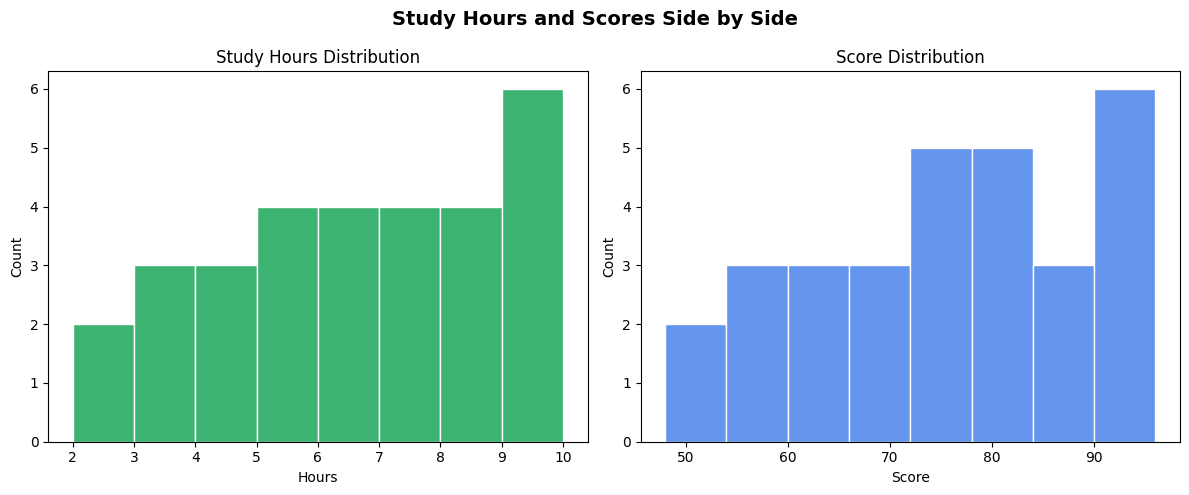

In [9]:
# 1 row, 2 columns of plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot
ax1.hist(df['study_hours'], bins=8, color='mediumseagreen', edgecolor='white')
ax1.set_title('Study Hours Distribution')
ax1.set_xlabel('Hours')
ax1.set_ylabel('Count')

# Right plot
ax2.hist(df['score'], bins=8, color='cornflowerblue', edgecolor='white')
ax2.set_title('Score Distribution')
ax2.set_xlabel('Score')
ax2.set_ylabel('Count')

fig.suptitle('Study Hours and Scores Side by Side', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

> `plt.subplots(1, 2)` → 1 row, 2 columns. Change numbers to get more plots.

---

## 🟡 STAGE 5 — Types of Data

Before picking a chart, ask: **how many variables am I looking at?**

| Term | Meaning | Example |
|------|---------|--------|
| **Univariate** | 1 variable | Distribution of scores |
| **Bivariate** | 2 variables | Score vs Study Hours |
| **Multivariate** | 3+ variables | Score vs Study Hours, split by Gender |

The chart type you choose depends on this.

---

## 🟡 STAGE 6 — Seaborn (Univariate Plots)

Seaborn makes beautiful plots with less code. It's built on top of matplotlib.

### 6a. Histogram with Seaborn

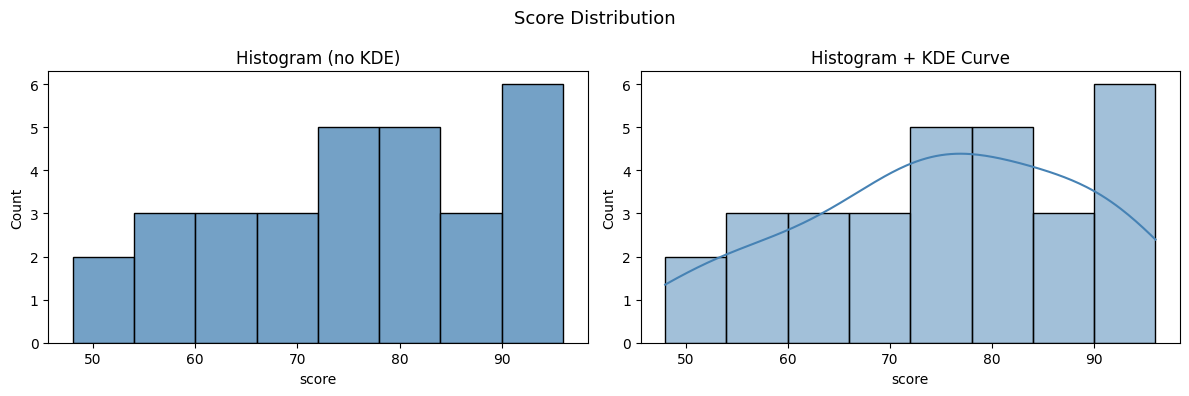

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Without KDE (just bars)
sns.histplot(df['score'], bins=8, kde=False, ax=ax1, color='steelblue')
ax1.set_title('Histogram (no KDE)')

# With KDE (smooth curve overlay)
sns.histplot(df['score'], bins=8, kde=True, ax=ax2, color='steelblue')
ax2.set_title('Histogram + KDE Curve')

fig.suptitle('Score Distribution', fontsize=13)
fig.tight_layout()
plt.show()

> **KDE** = Kernel Density Estimation. It's a smooth curve that estimates the shape of the distribution.

### 6b. KDE Plot (Density Plot)

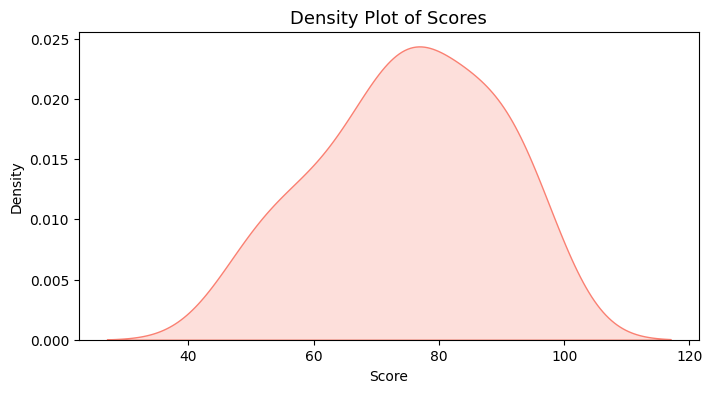

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(data=df, x='score', ax=ax, fill=True, color='salmon')

ax.set_title('Density Plot of Scores', fontsize=13)
ax.set_xlabel('Score')
plt.show()

> Use a KDE plot when you care about the **shape** of the distribution, not the exact counts.

### 6c. Rug Plot

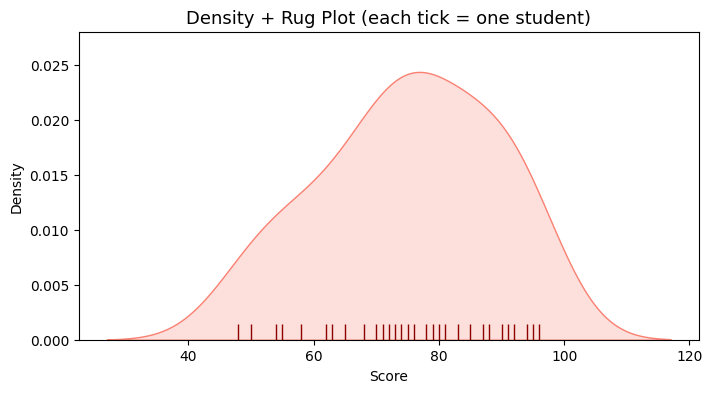

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(data=df, x='score', ax=ax, fill=True, color='salmon')
sns.rugplot(data=df, x='score', ax=ax, color='darkred', height=0.05)

ax.set_title('Density + Rug Plot (each tick = one student)', fontsize=13)
ax.set_xlabel('Score')
plt.show()

> **Rug plot**: each small tick mark on the x-axis represents one data point. Usually layered on top of another plot.

### 6d. Count Plot (Bar Chart of Categories)

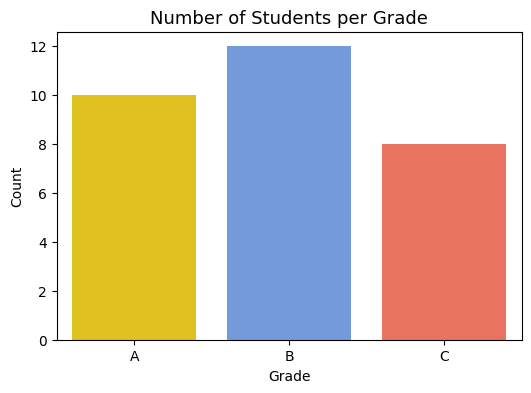

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(x='grade', data=df, order=['A', 'B', 'C'], ax=ax,
              palette=['gold', 'cornflowerblue', 'tomato'])

ax.set_title('Number of Students per Grade', fontsize=13)
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
plt.show()

> Use `countplot` when you want to count how many items fall into each category.

---

## 🟡 STAGE 7 — Seaborn (Bivariate Plots)

Now we look at **two variables at once**.

### 7a. Scatter Plot with Regression Line

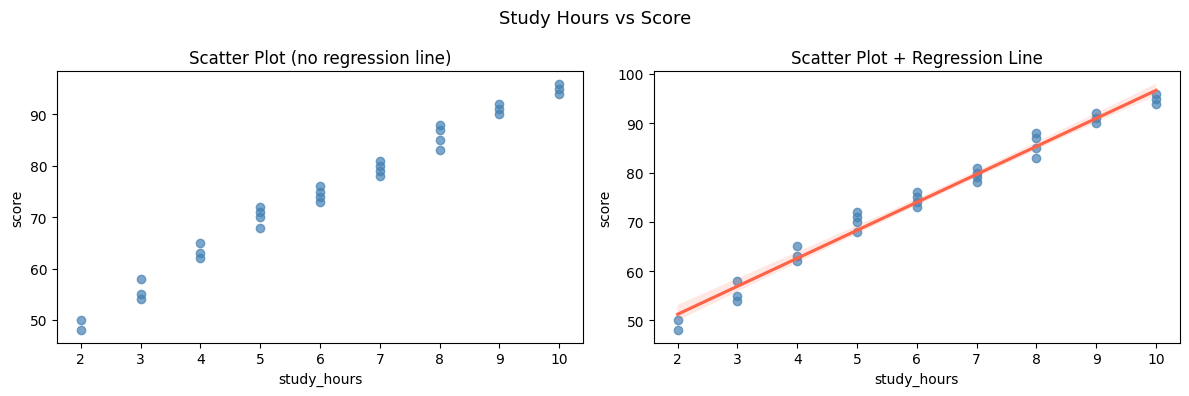

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Without regression line
sns.regplot(x='study_hours', y='score', data=df, ax=ax1, fit_reg=False,
            scatter_kws={'color': 'steelblue', 'alpha': 0.7})
ax1.set_title('Scatter Plot (no regression line)')

# With regression line
sns.regplot(x='study_hours', y='score', data=df, ax=ax2,
            scatter_kws={'color': 'steelblue', 'alpha': 0.7},
            line_kws={'color': 'tomato'})
ax2.set_title('Scatter Plot + Regression Line')

fig.suptitle('Study Hours vs Score', fontsize=13)
fig.tight_layout()
plt.show()

> The **regression line** shows the overall trend. Sloping up = positive relationship.

### 7b. Joint Plot — Scatter + Marginal Distributions

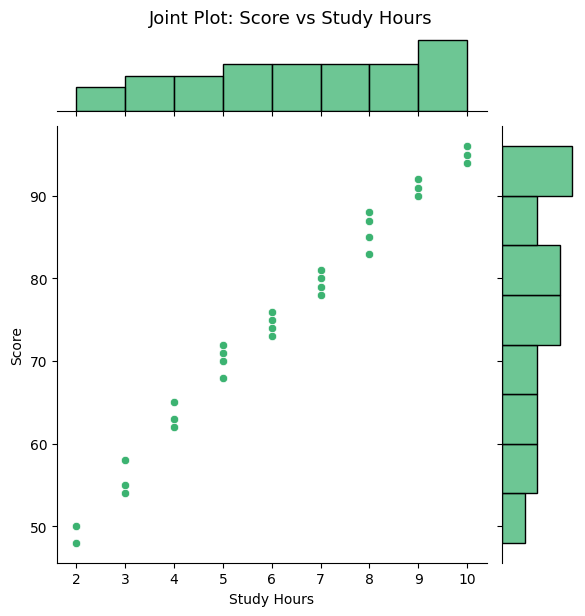

In [15]:
g = sns.jointplot(x='study_hours', y='score', data=df, kind='scatter',
                  color='mediumseagreen', marginal_kws={'bins': 8})
g.set_axis_labels('Study Hours', 'Score')
g.figure.suptitle('Joint Plot: Score vs Study Hours', y=1.02, fontsize=13)
plt.show()

> **Joint plot** = scatter in the middle + histogram on the top and right. Three plots in one!

### 7c. Hexbin Plot

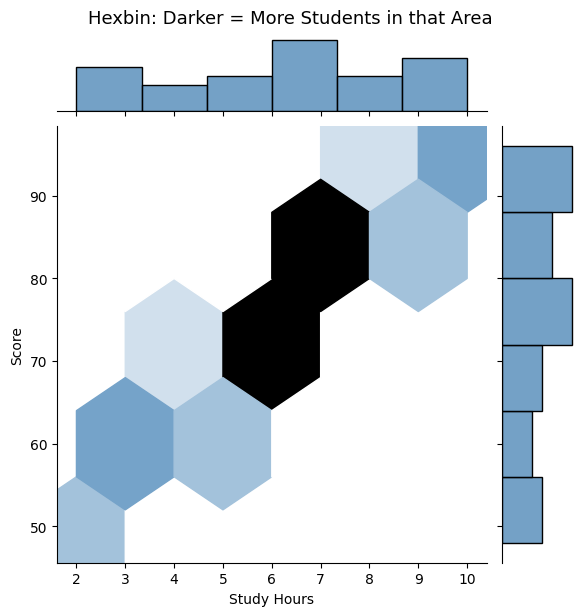

In [16]:
g = sns.jointplot(x='study_hours', y='score', data=df, kind='hex', color='steelblue')
g.set_axis_labels('Study Hours', 'Score')
g.figure.suptitle('Hexbin: Darker = More Students in that Area', y=1.02, fontsize=13)
plt.show()

> **Hexbin** groups nearby dots into hexagons. Darker = more data points in that region. Useful when you have many overlapping points.

### 7d. 2D Density Plot

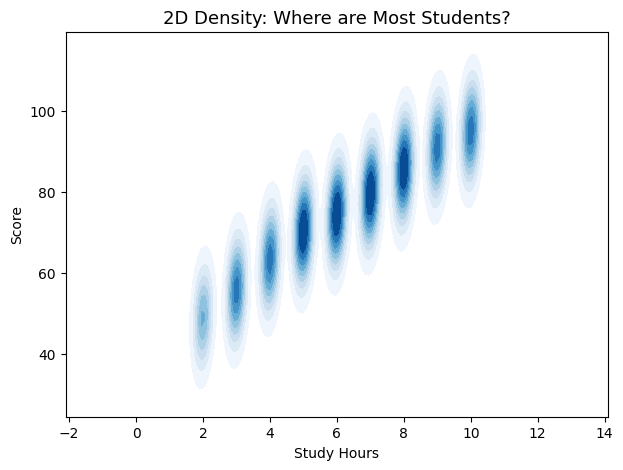

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.kdeplot(x=df['study_hours'], y=df['score'], fill=True, cmap='Blues', ax=ax)

ax.set_title('2D Density: Where are Most Students?', fontsize=13)
ax.set_xlabel('Study Hours')
ax.set_ylabel('Score')
plt.show()

> Like a KDE but for 2 variables. Darker blue = more students in that combination of hours and score.

### 7e. Bar Plot (Mean by Category)

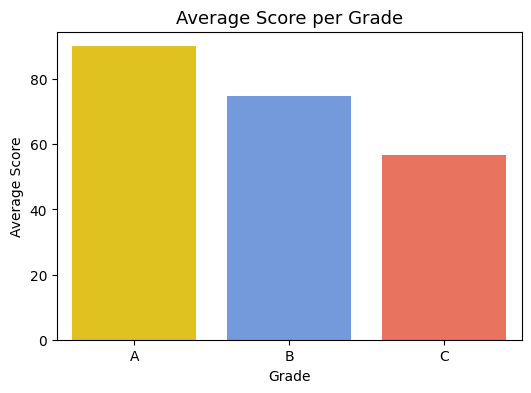

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(x='grade', y='score', data=df, order=['A', 'B', 'C'], ax=ax,
            palette=['gold', 'cornflowerblue', 'tomato'], errorbar=None)

ax.set_title('Average Score per Grade', fontsize=13)
ax.set_xlabel('Grade')
ax.set_ylabel('Average Score')
plt.show()

> By default, `barplot` shows the **mean** (average) for each category.

---

## 🟡 STAGE 8 — Distributions and Comparisons

### 8a. Box Plot with Seaborn

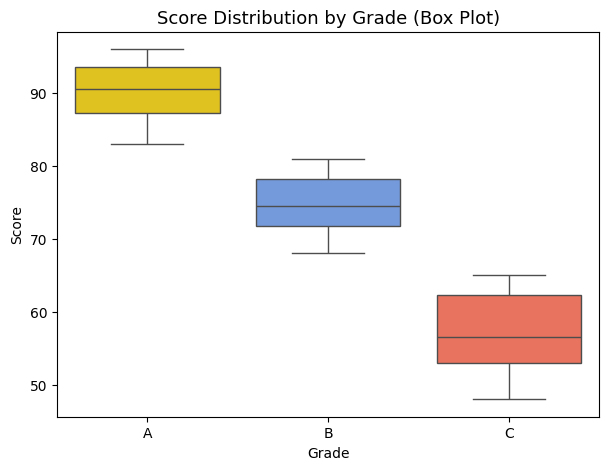

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(x='grade', y='score', data=df, order=['A', 'B', 'C'], ax=ax,
            palette=['gold', 'cornflowerblue', 'tomato'])

ax.set_title('Score Distribution by Grade (Box Plot)', fontsize=13)
ax.set_xlabel('Grade')
ax.set_ylabel('Score')
plt.show()

### 8b. Violin Plot — Box Plot + Distribution Shape

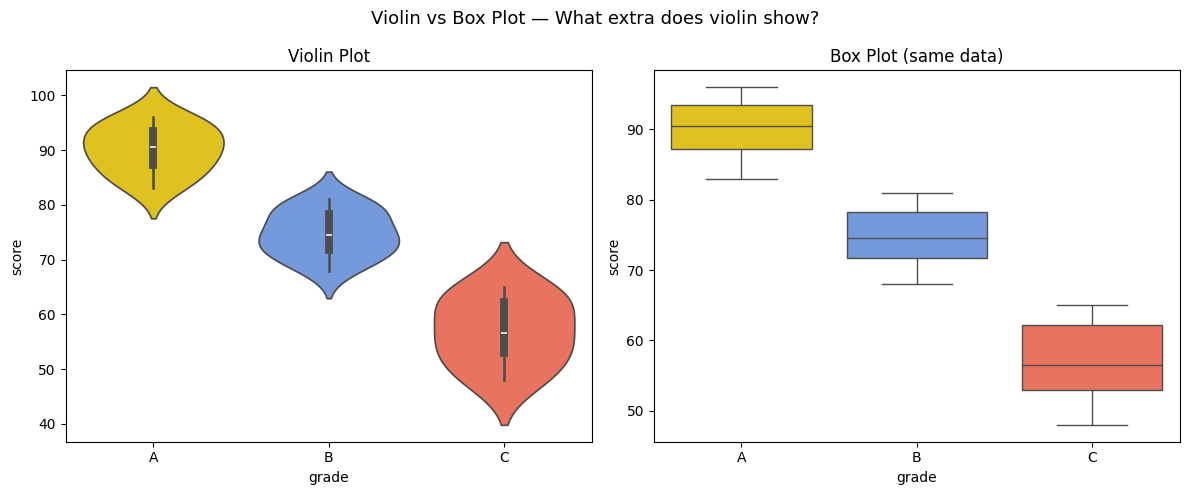

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Without split
sns.violinplot(x='grade', y='score', data=df, order=['A', 'B', 'C'], ax=ax1,
               palette=['gold', 'cornflowerblue', 'tomato'])
ax1.set_title('Violin Plot')

# Box plot for comparison
sns.boxplot(x='grade', y='score', data=df, order=['A', 'B', 'C'], ax=ax2,
            palette=['gold', 'cornflowerblue', 'tomato'])
ax2.set_title('Box Plot (same data)')

fig.suptitle('Violin vs Box Plot — What extra does violin show?', fontsize=13)
fig.tight_layout()
plt.show()

> A **violin plot** is a box plot + KDE. The wider the violin, the more students at that score.

---

## 🟡 STAGE 9 — Multivariate Data with `hue`

What if we want to see **3 variables** at once?  
Use the `hue` parameter to add a **color dimension**.

### 9a. Scatter with hue

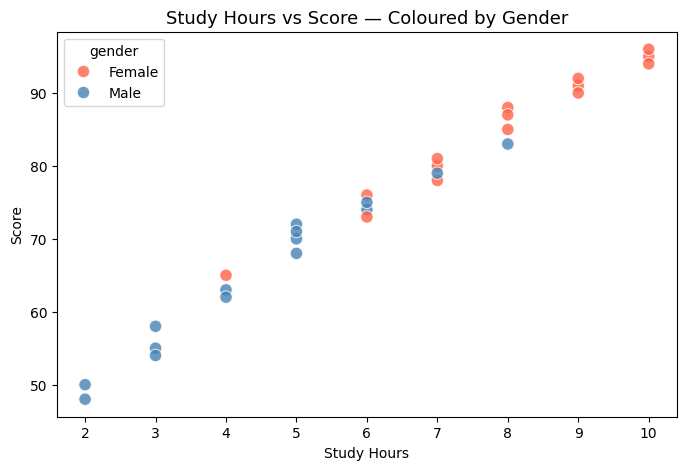

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(x='study_hours', y='score', hue='gender', data=df,
                ax=ax, palette={'Female': 'tomato', 'Male': 'steelblue'},
                s=80, alpha=0.8)

ax.set_title('Study Hours vs Score — Coloured by Gender', fontsize=13)
ax.set_xlabel('Study Hours')
ax.set_ylabel('Score')
plt.show()

### 9b. Violin Plot Split by Gender

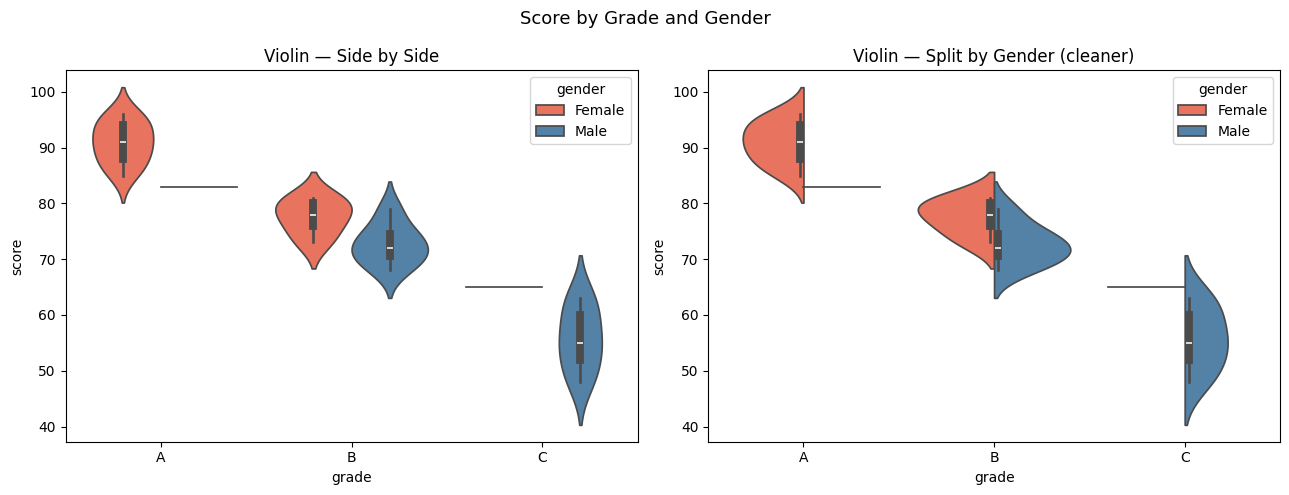

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Side by side
sns.violinplot(x='grade', y='score', hue='gender', data=df,
               order=['A', 'B', 'C'], ax=ax1,
               palette={'Female': 'tomato', 'Male': 'steelblue'})
ax1.set_title('Violin — Side by Side')

# Split (cleaner)
sns.violinplot(x='grade', y='score', hue='gender', data=df,
               order=['A', 'B', 'C'], split=True, ax=ax2,
               palette={'Female': 'tomato', 'Male': 'steelblue'})
ax2.set_title('Violin — Split by Gender (cleaner)')

fig.suptitle('Score by Grade and Gender', fontsize=13)
fig.tight_layout()
plt.show()

> `split=True` puts the two genders on opposite halves of the same violin — easier to compare.

---

## 🟡 STAGE 10 — Pairwise Plots

What if you want to see **all numeric variables** plotted against each other?

### 10a. Pair Plot (quick overview)

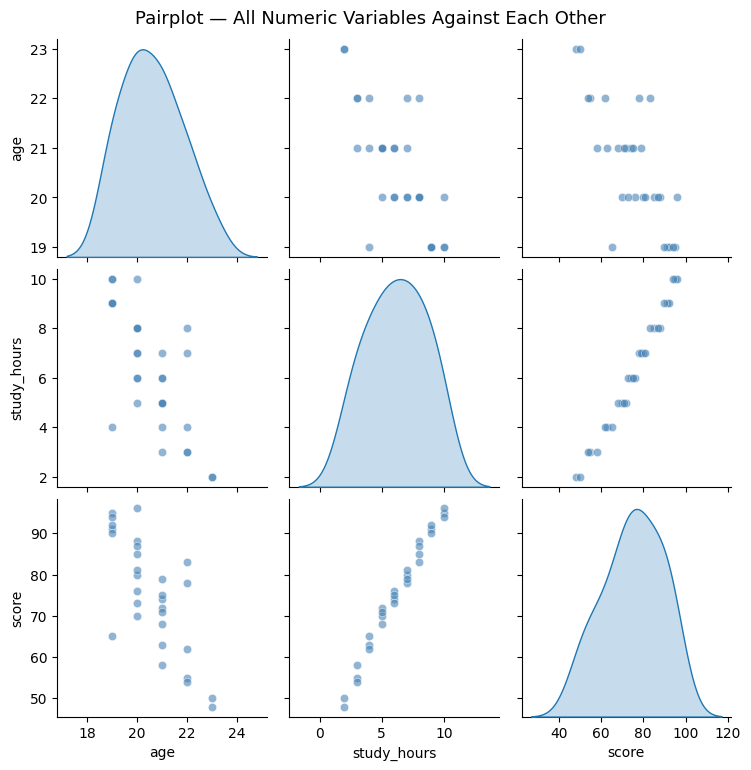

In [23]:
numeric_df = df[['age', 'study_hours', 'score']]

sns.pairplot(numeric_df, diag_kind='kde', plot_kws={'alpha': 0.6, 'color': 'steelblue'})
plt.suptitle('Pairplot — All Numeric Variables Against Each Other', y=1.02, fontsize=13)
plt.show()

> The **diagonal** shows the distribution of each variable.  
> The **off-diagonal** plots show relationships between pairs of variables.

### 10b. Pair Grid — Customised (advanced)

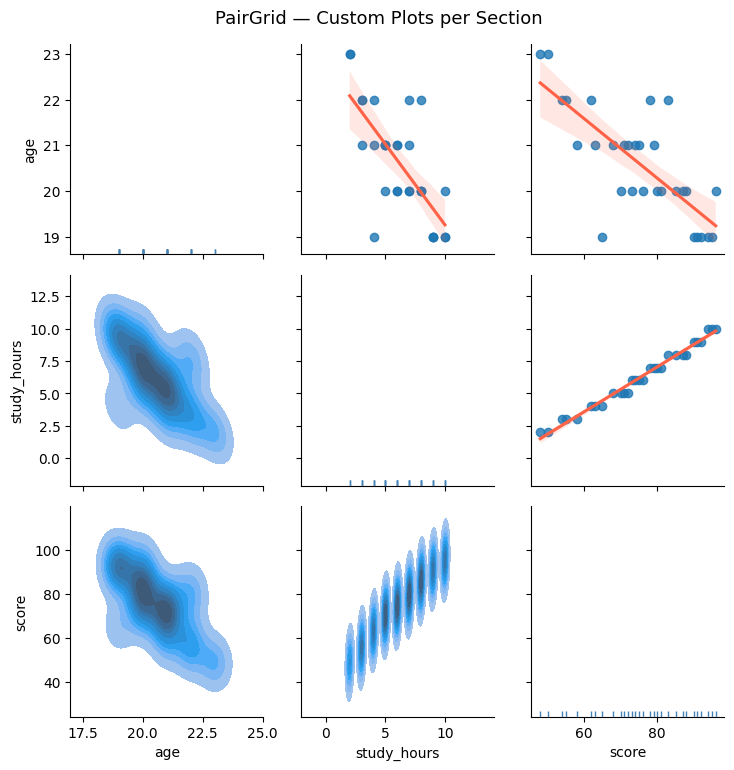

In [24]:
pair_grid = sns.PairGrid(data=numeric_df)

pair_grid = pair_grid.map_upper(sns.regplot, line_kws={'color': 'tomato'})   # top half: scatter + line
pair_grid = pair_grid.map_lower(sns.kdeplot, fill=True)                      # bottom half: density
pair_grid = pair_grid.map_diag(sns.rugplot, color='steelblue')               # diagonal: rug

plt.suptitle('PairGrid — Custom Plots per Section', y=1.02, fontsize=13)
plt.show()

> `PairGrid` gives you full control: different plot types for upper triangle, lower triangle, and diagonal.

---

## 🟡 STAGE 11 — Seaborn Styles

Seaborn has 5 built-in styles. Call `sns.set_style()` once at the top of your code.

| Style | Best for |
|-------|---------|
| `darkgrid` | Default, great for data-heavy charts |
| `whitegrid` | Clean, professional look |
| `dark` | No grid, dark background |
| `white` | No grid, white background |
| `ticks` | Minimal — just tick marks, no grid |

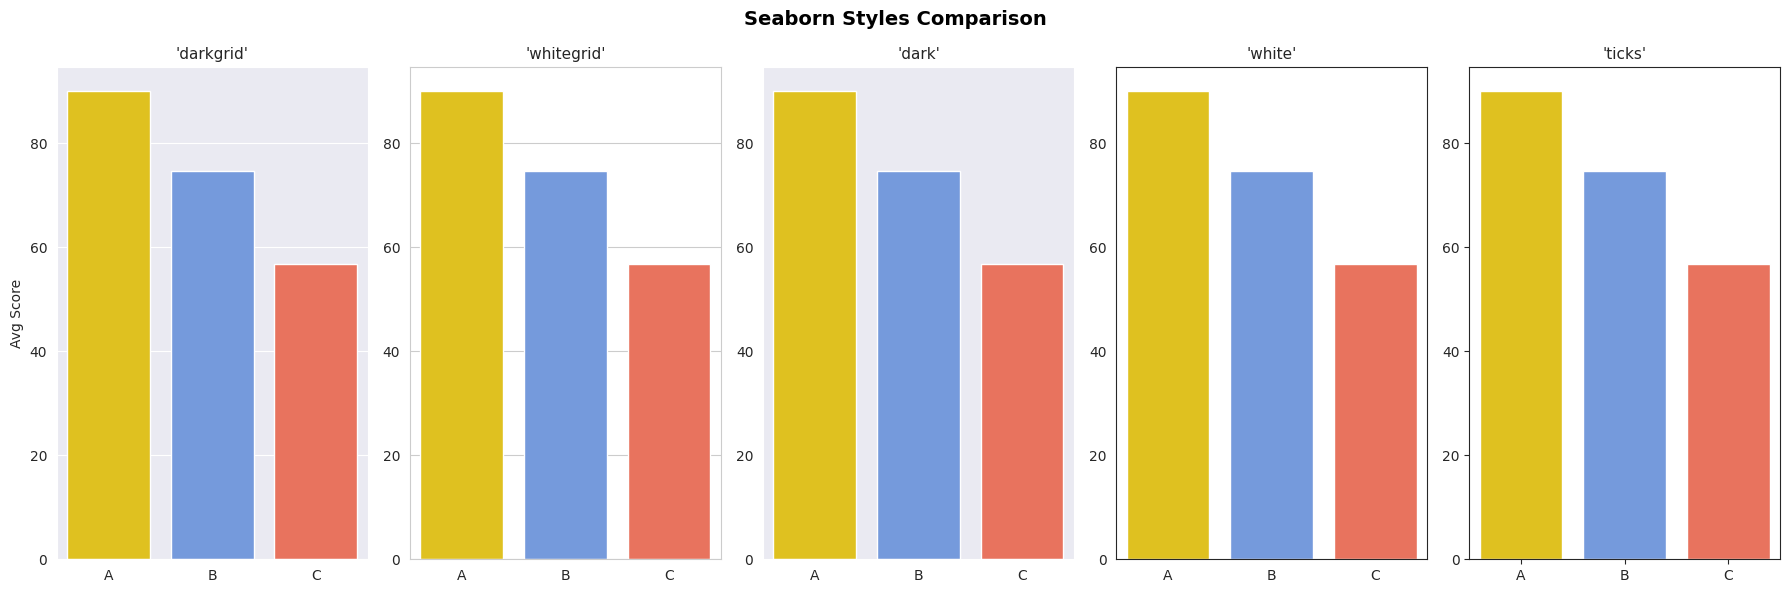

In [25]:
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

fig = plt.figure(figsize=(18, 6))

for idx, style in enumerate(styles):
    with sns.axes_style(style):
        ax = fig.add_subplot(1, 5, idx + 1)
        sns.barplot(x='grade', y='score', data=df, order=['A', 'B', 'C'], ax=ax,
                    palette=['gold', 'cornflowerblue', 'tomato'], errorbar=None)
        ax.set_title(f"'{style}'", fontsize=11)
        ax.set_xlabel('')
        ax.set_ylabel('Avg Score' if idx == 0 else '')

fig.suptitle('Seaborn Styles Comparison', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

---

## 🟡 STAGE 12 — Pandas Built-in Plotting

Pandas has its own `.plot` shortcuts — fewer lines of code, useful for quick exploration.

Format: `df['column'].plot.CHART_TYPE()` or `df.plot.CHART_TYPE()`

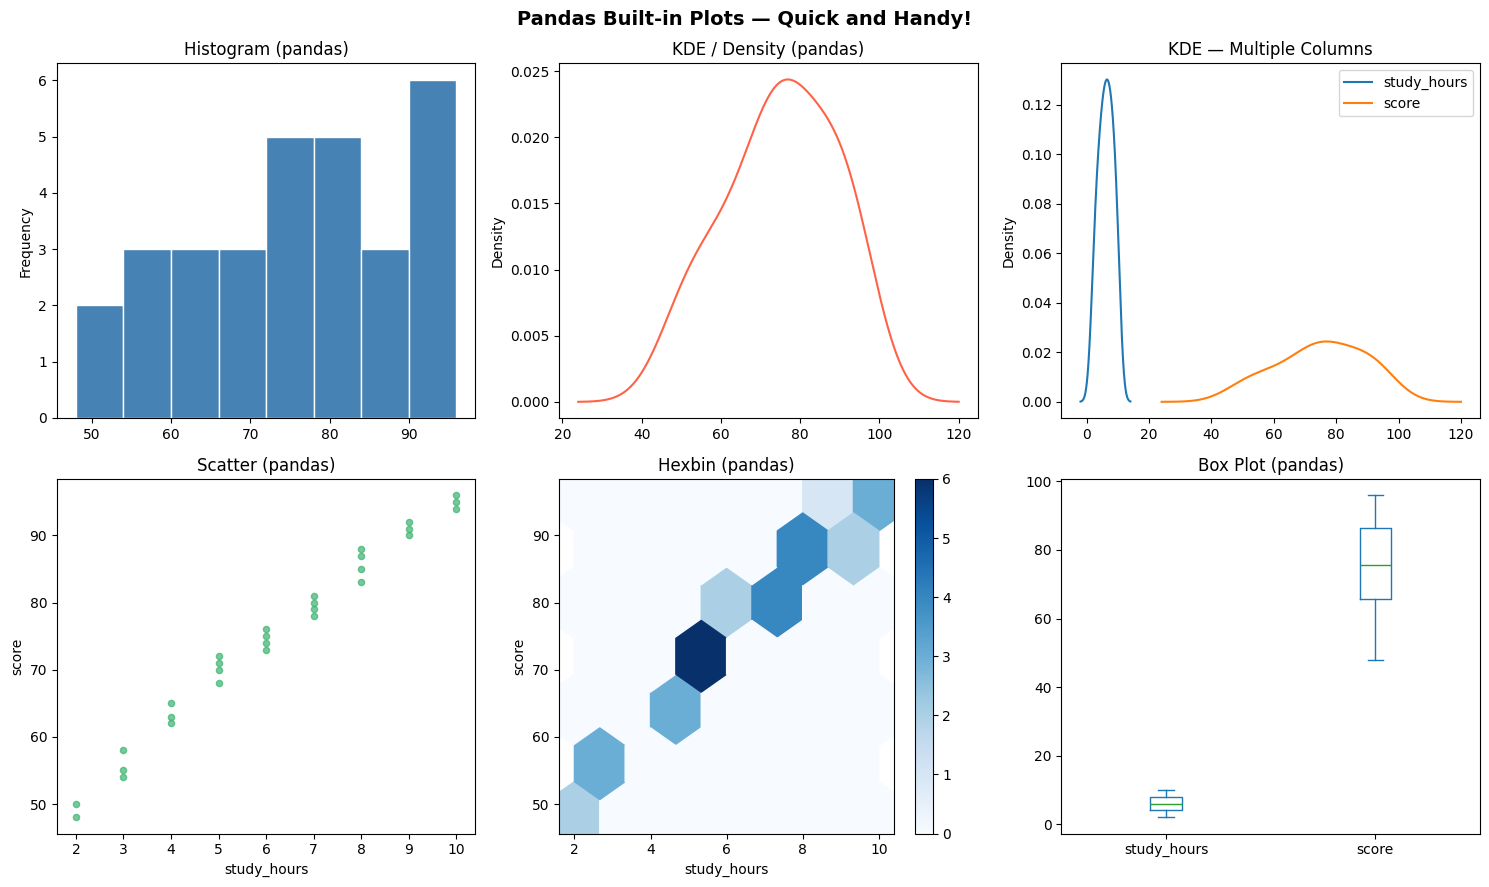

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Histogram — single column
df['score'].plot.hist(bins=8, ax=axes[0, 0], color='steelblue', edgecolor='white')
axes[0, 0].set_title('Histogram (pandas)')

# 2. KDE — single column
df['score'].plot.kde(ax=axes[0, 1], color='tomato')
axes[0, 1].set_title('KDE / Density (pandas)')

# 3. KDE — multiple columns
df[['study_hours', 'score']].plot.kde(ax=axes[0, 2])
axes[0, 2].set_title('KDE — Multiple Columns')

# 4. Scatter
df.plot.scatter(x='study_hours', y='score', ax=axes[1, 0],
                color='mediumseagreen', alpha=0.7)
axes[1, 0].set_title('Scatter (pandas)')

# 5. Hexbin
df.plot.hexbin(x='study_hours', y='score', gridsize=6,
               ax=axes[1, 1], colormap='Blues')
axes[1, 1].set_title('Hexbin (pandas)')

# 6. Box plot
df[['study_hours', 'score']].plot.box(ax=axes[1, 2])
axes[1, 2].set_title('Box Plot (pandas)')

fig.suptitle('Pandas Built-in Plots — Quick and Handy!', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

> Pandas plotting is great for **quick exploration**. Use matplotlib/seaborn for **presentation-quality** charts.

---

## ✅ Summary — What We Covered

| Stage | Topic | Key Takeaway |
|-------|-------|--------------|
| 1 | Why visualize? | Numbers can lie — plots reveal the truth |
| 2 | Setup & data loading | Import pandas, matplotlib, seaborn; use `%matplotlib inline` |
| 3 | Figure anatomy | Figure > Axes > Axis |
| 4 | Matplotlib basics | Histogram, scatter, box plot, subplots |
| 5 | Types of data | Univariate, Bivariate, Multivariate |
| 6 | Seaborn univariate | `histplot`, `kdeplot`, `rugplot`, `countplot` |
| 7 | Seaborn bivariate | `regplot`, `jointplot`, hexbin, 2D KDE, `barplot` |
| 8 | Distributions | Box plot vs Violin plot |
| 9 | Multivariate | `hue` parameter, `split` violin |
| 10 | Pairwise plots | `pairplot`, `PairGrid` |
| 11 | Seaborn styles | `darkgrid`, `whitegrid`, `dark`, `white`, `ticks` |
| 12 | Pandas plotting | `.plot.hist()`, `.plot.kde()`, `.plot.scatter()`, `.plot.box()` |

---

## 🏁 Quick Reference — Which chart should I use?

```
1 variable (numeric)    →  Histogram or KDE
1 variable (category)   →  Count Plot (bar)
2 numeric variables     →  Scatter Plot or Hexbin
1 numeric + 1 category  →  Box Plot or Violin Plot
All pairs of variables  →  Pair Plot
Add a 3rd variable      →  Use hue= for color
```

---
*End of notebook — Happy Plotting! 📊*